# ⚡ Energy Lab — Partie 2 : le frigo, de nouvelles features

Dans la Partie 1, une fenêtre courte suffisait à savoir si le compresseur était
ON ou OFF : moyenne et écart-type séparaient parfaitement les deux états.

Ici on change de question : peut-on caractériser le **rythme** du frigo lui-même —
sans même connaître de seuil ON/OFF — à partir d'une longue plage de mesures ?
Utilité concrète : repérer un frigo qui **vieillit** (cycles plus rapides,
signe d'usure) alors que sa consommation moyenne ne change presque pas.

**Ce qu'on va apprendre :**
1. Un cas où moyenne et écart-type ne suffisent plus
2. La FFT : décomposer un signal en fréquences
3. L'autocorrélation : retrouver le même rythme par un chemin différent
4. Les ondelettes : localiser un évènement dans le temps
5. Comparer plusieurs familles de features, et vérifier lesquelles séparent vraiment

> `Shift+Enter` pour exécuter une cellule. Dans les exercices, essaie de répondre
> **avant** de regarder la cellule de correction qui suit — la réponse y est
> affichée, ça ne sert à rien de la lire avant d'avoir cherché toi-même !

![title](pictures/cyberpunk_engraving_title_1784108576637.png)


In [1]:
import random as _random_qcm
import ipywidgets as w
from IPython.display import display

_RELANCES_HUMOUR = [
    "Le compresseur du frigo a plus de constance que cette réponse.",
    "Pas grave, même le capteur Linky se trompe parfois (façon de parler).",
    "On va dire que c'était un test de tes réflexes, pas de tes connaissances.",
    "Presque ! Enfin... pas vraiment, mais l'intention y était.",
    "Aïe. Même le bruit gaussien ±8 W est plus proche de la vérité.",
    "Retente ta chance, le frigo ne t'en voudra pas.",
]

def qcm(question, options, correct, explication=""):
    """
    Affiche un QCM interactif.
    correct : index (int) ou liste d'index de la/des bonne(s) réponse(s).
    """
    if isinstance(correct, int):
        correct = [correct]

    boutons = w.RadioButtons(options=options, layout=w.Layout(width='100%'))
    sortie  = w.Output()
    titre   = w.HTML(f"<b>❓ {question}</b>")

    def verifier(change):
        idx = options.index(change['new'])
        sortie.clear_output()
        with sortie:
            if idx in correct:
                display(w.HTML(
                    f"<div style='padding:8px;border-radius:6px;background:#d4edda;color:#155724'>"
                    f"✅ <b>Correct !</b> {explication}</div>"
                ))
            else:
                humour = _random_qcm.choice(_RELANCES_HUMOUR)
                display(w.HTML(
                    f"<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>"
                    f"❌ <b>Pas tout à fait.</b> {humour}<br>"
                    f"<b>Pourquoi ce n'est pas ça :</b> {explication}</div>"
                ))

    boutons.observe(verifier, names='value')
    display(w.VBox([titre, boutons, sortie]))


def check(nom, valeur, attendu, tol=1e-6):
    """
    Vérifie la valeur d'une variable calculée dans un exercice, et affiche
    un feedback stylé (comme qcm(), mais pour du code plutôt qu'un choix).
    """
    try:
        if isinstance(attendu, (int, float)) and isinstance(valeur, (int, float)):
            ok = abs(valeur - attendu) <= tol
        else:
            ok = valeur == attendu
    except Exception:
        ok = False

    if ok:
        display(w.HTML(
            f"<div style='padding:8px;border-radius:6px;background:#d4edda;color:#155724'>"
            f"✅ <b>{nom}</b> correct : {valeur}</div>"
        ))
    else:
        display(w.HTML(
            f"<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>"
            f"❌ <b>{nom}</b> incorrect. Ta valeur : {valeur} — attendu proche de {attendu}.</div>"
        ))
    return ok

print("✅ Fonctions qcm() et check() prêtes.")

✅ Fonctions qcm() et check() prêtes.


---
# Partie 2 — Le frigo, de nouvelles features

## 2.1 · Deux frigos, une seule question : lequel s'use ?

On simule deux frigos sur une nuit de 8h (même génération que la Partie 1) :

- **Frigo sain** : cycles 10 min ON / 20 min OFF (identique à la Partie 1)
- **Frigo fatigué** : cycles 6 min ON / 12 min OFF — un joint de porte qui fuit
  ou un gaz réfrigérant faible obligent le compresseur à redémarrer plus souvent,
  **avec le même ratio ON/OFF** (donc le même *duty cycle*)

Les deux frigos ont donc la même fraction de temps ON, la même puissance ON/OFF,
le même bruit de mesure. Seul le **rythme** change.

In [2]:
import random
import numpy as np

def generer_frigo(duree_on_s, duree_off_s, duree_totale_h=8,
                   puissance_on=150, puissance_off=30, bruit=8,
                   alea_duree=0.25, seed=42):
    """Génère un signal de frigo — même logique que la Partie 1, paramétrable."""
    rng = random.Random(seed)
    N = duree_totale_h * 3600 // 10
    signal = []
    i = 0
    en_on = True
    duree_restante = round(duree_on_s * rng.uniform(1 - alea_duree, 1 + alea_duree)) // 10
    while i < N:
        if duree_restante <= 0:
            en_on = not en_on
            base = duree_on_s if en_on else duree_off_s
            duree_restante = round(base * rng.uniform(1 - alea_duree, 1 + alea_duree)) // 10
        p = puissance_on if en_on else puissance_off
        p += rng.gauss(0, bruit)
        signal.append(max(0, p))
        duree_restante -= 1
        i += 1
    return np.array(signal)

# Frigo sain : identique à la Partie 1 (cycle théorique de 30 min)
frigo_sain = generer_frigo(duree_on_s=10 * 60, duree_off_s=20 * 60, seed=42)

# Frigo fatigué : même duty cycle (1/3 ON), cycle théorique de 18 min
frigo_fatigue = generer_frigo(duree_on_s=6 * 60, duree_off_s=12 * 60, seed=7)

N = len(frigo_sain)
heures = np.arange(N) * 10 / 3600

print(f"{N} points par signal ({N * 10 / 3600:.0f} h de mesures)")
print(f"Frigo sain    : cycle théorique = 30 min, duty cycle = {10 / 30:.0%}")
print(f"Frigo fatigué : cycle théorique = 18 min, duty cycle = {6 / 18:.0%}")

2880 points par signal (8 h de mesures)
Frigo sain    : cycle théorique = 30 min, duty cycle = 33%
Frigo fatigué : cycle théorique = 18 min, duty cycle = 33%


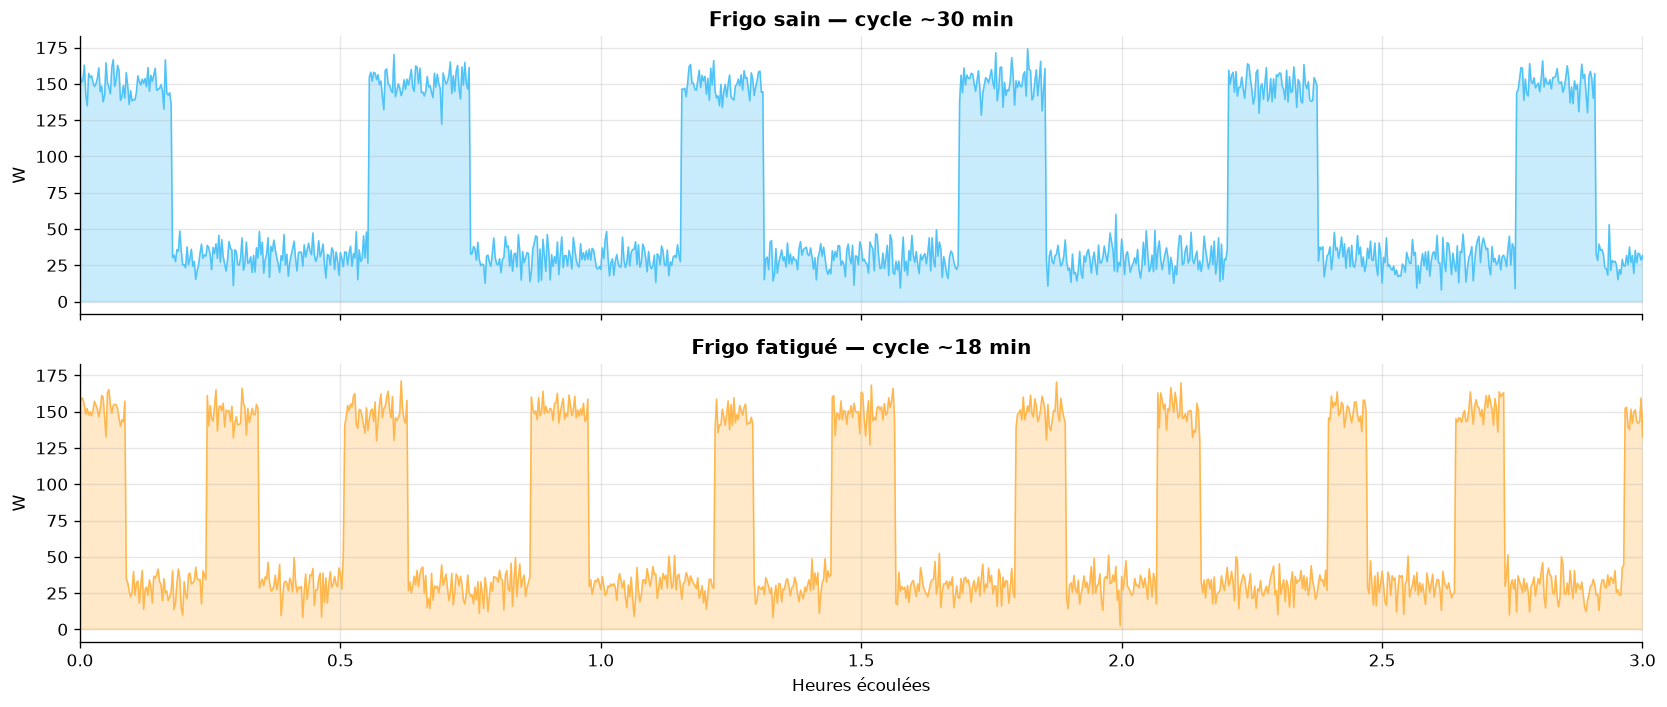

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
for ax, sig, titre, coul in zip(
    axes,
    [frigo_sain, frigo_fatigue],
    ['Frigo sain — cycle ~30 min', 'Frigo fatigué — cycle ~18 min'],
    ['#4fc3f7', '#ffb74d'],
):
    ax.plot(heures, sig, color=coul, lw=0.9)
    ax.fill_between(heures, sig, alpha=0.3, color=coul)
    ax.set_title(titre, fontweight='bold')
    ax.set_ylabel('W')
    ax.set_xlim(0, 3)   # zoom sur les 3 premières heures pour bien voir le rythme

axes[-1].set_xlabel('Heures écoulées')
plt.tight_layout()
plt.show()

**Exercice** — avant de voir la comparaison complète, calcule toi-même la moyenne
et l'écart-type de `frigo_fatigue` et stocke-les dans les variables `moyenne_fatigue`
et `ecart_type_fatigue`. Exécute ensuite la cellule de test juste après.

In [ ]:
# À toi de jouer : calcule moyenne_fatigue et ecart_type_fatigue
moyenne_fatigue = ...
ecart_type_fatigue = ...

In [ ]:
# Cellule de test — vérifie ta réponse ci-dessus
check("moyenne_fatigue", moyenne_fatigue, frigo_fatigue.mean(), tol=0.5)
check("ecart_type_fatigue", ecart_type_fatigue, frigo_fatigue.std(), tol=0.5)

Maintenant qu'on a la valeur de `frigo_fatigue`, comparons-la à `frigo_sain`.

In [6]:
print("=== Comparaison des statistiques de la Partie 1, sur le signal complet ===")
for nom, sig in [('Frigo sain', frigo_sain), ('Frigo fatigué', frigo_fatigue)]:
    print(f"{nom:15s} moyenne = {sig.mean():6.1f} W   écart-type = {sig.std():5.1f} W")

=== Comparaison des statistiques de la Partie 1, sur le signal complet ===
Frigo sain      moyenne =   70.7 W   écart-type =  57.3 W
Frigo fatigué   moyenne =   70.3 W   écart-type =  57.1 W


In [7]:
qcm(
    "Les moyennes et écarts-types des deux frigos sont quasiment identiques. "
    "D'après le nuage de points moyenne vs écart-type de la Partie 1, pourrait-on "
    "distinguer un frigo sain d'un frigo fatigué avec ces deux seules features ?",
    [
        "Oui, l'écart-type suffit toujours à distinguer deux signaux différents",
        "Non — les deux frigos ont le même duty cycle, donc la même moyenne et le même écart-type",
        "Oui, car le frigo fatigué a une puissance ON plus élevée",
        "Non, car les deux frigos n'ont pas le même bruit de mesure",
    ],
    correct=1,
    explication="Moyenne et écart-type d'un signal ON/OFF ne dépendent que du <i>duty cycle</i> "
                "et des niveaux de puissance — pas de la vitesse à laquelle on bascule entre les deux. "
                "Deux frigos avec le même duty cycle sont donc invisibles à ces deux features, "
                "même si l'un cycle deux fois plus vite que l'autre."
)

In [8]:
qcm(
    "Pourquoi un joint de porte qui fuit fait-il cycler un frigo plus souvent, "
    "sans forcément changer son duty cycle ?",
    [
        "Le compresseur devient plus puissant pour compenser la fuite",
        "Le froid s'échappe plus vite, donc la température remonte plus vite : "
        "le compresseur redémarre plus tôt, mais tourne aussi moins longtemps à chaque fois",
        "Le thermostat se dérègle et impose des cycles aléatoires",
        "La fuite n'a aucun effet sur le rythme, seulement sur la puissance",
    ],
    correct=1,
    explication="Une mauvaise isolation accélère la remontée en température : le compresseur "
                "redémarre plus vite (cycle plus court), mais comme il refroidit aussi plus vite "
                "qu'il ne perd la fraîcheur, la proportion de temps ON peut rester similaire. "
                "C'est un schéma classique de <i>short cycling</i> en maintenance prédictive."
)

![section1](pictures/cyberpunk_engraving_section1_1784108662188.png)


## 2.2 · La FFT — voir le rythme dans le domaine fréquentiel

La **FFT** (Fast Fourier Transform) décompose un signal en une somme de sinusoïdes.
Le résultat est un *spectre* : à quelle fréquence retrouve-t-on le plus d'énergie
dans le signal ?

Un frigo qui cycle toutes les 30 minutes a un pic de puissance spectrale à la
fréquence `f = 1 / (30 × 60) ≈ 5.6×10⁻⁴ Hz`. Inversement, si on repère un pic à une
fréquence `f`, la période correspondante est `1 / f`.

```python
spectre = np.fft.rfft(signal - signal.mean())   # on retire la moyenne (composante continue)
freqs   = np.fft.rfftfreq(len(signal), d=10)     # d = pas d'échantillonnage en secondes
puissance_spectrale = np.abs(spectre) ** 2
```

On retire la moyenne avant la FFT car sinon toute l'énergie du signal se concentre
dans la case `f = 0` (la composante continue), qui écraserait visuellement les pics
qui nous intéressent.

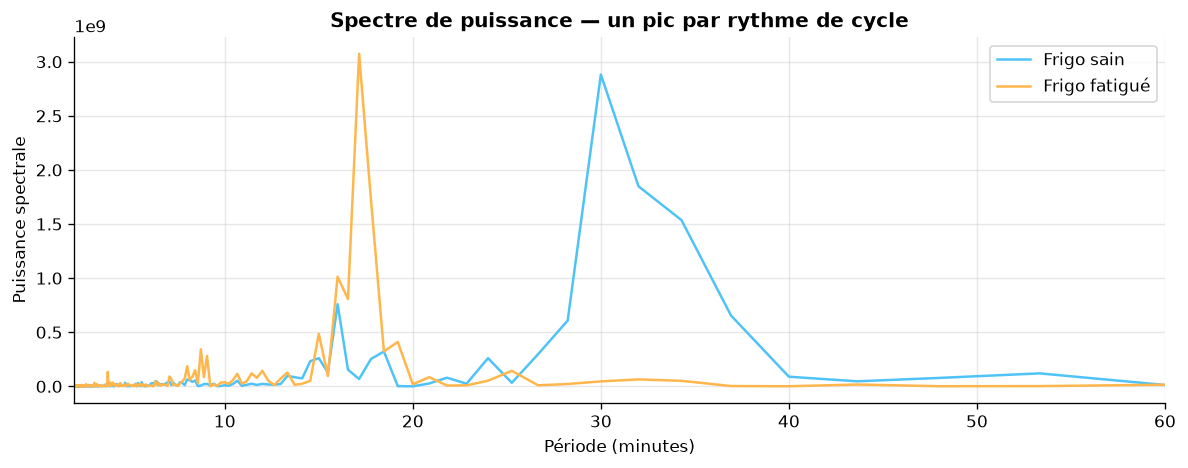

Deux pics nettement séparés, à des fréquences différentes : la vitesse de
cyclage de chaque frigo devient visible dans le domaine fréquentiel.


In [9]:
def spectre_puissance(signal, dt=10):
    """FFT d'un signal 1D : renvoie (fréquences en Hz, puissance spectrale)."""
    signal  = np.asarray(signal, dtype=float)
    spectre = np.fft.rfft(signal - signal.mean())
    freqs   = np.fft.rfftfreq(len(signal), d=dt)
    return freqs, np.abs(spectre) ** 2

freqs_sain, p_sain       = spectre_puissance(frigo_sain)
freqs_fatigue, p_fatigue = spectre_puissance(frigo_fatigue)

# On ignore la case f=0 (composante continue déjà retirée) et on affiche en
# période (minutes) plutôt qu'en fréquence — plus intuitif à lire.
periode_sain    = 1 / freqs_sain[1:] / 60
periode_fatigue = 1 / freqs_fatigue[1:] / 60

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(periode_sain, p_sain[1:], color='#4fc3f7', label='Frigo sain')
ax.plot(periode_fatigue, p_fatigue[1:], color='#ffb74d', label='Frigo fatigué')
ax.set_xlim(2, 60)
ax.set_xlabel('Période (minutes)')
ax.set_ylabel('Puissance spectrale')
ax.set_title('Spectre de puissance — un pic par rythme de cycle', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Deux pics nettement séparés, à des fréquences différentes : la vitesse de")
print("cyclage de chaque frigo devient visible dans le domaine fréquentiel.")

In [10]:
def periode_dominante_min(signal, dt=10):
    """Période (en minutes) du pic dominant du spectre de puissance."""
    freqs, p = spectre_puissance(signal, dt)
    idx = np.argmax(p[1:]) + 1   # on exclut l'indice 0 (f=0, déjà retiré)
    return 1 / freqs[idx] / 60

# On vérifie l'outil sur le frigo sain, dont on connaît la valeur théorique (30 min)
print(f"Période dominante — frigo sain : {periode_dominante_min(frigo_sain):.1f} min (théorique : 30 min)")

Période dominante — frigo sain : 30.0 min (théorique : 30 min)


In [11]:
qcm(
    "Le spectre d'un signal affiche un pic à f = 4.6×10⁻⁴ Hz. "
    "Quelle est la période du cycle correspondant, en minutes (arrondie) ?",
    ["9 min", "24 min", "36 min", "60 min"],
    correct=2,
    explication="Période = 1 / f = 1 / 4.6×10⁻⁴ ≈ 2174 s ≈ 36.2 min, soit environ 36 min."
)

In [12]:
qcm(
    "Dans `spectre_puissance()`, pourquoi calcule-t-on `signal - signal.mean()` "
    "avant d'appeler `np.fft.rfft()` ?",
    [
        "C'est obligatoire, sinon numpy renvoie une erreur",
        "Cela réduit le bruit de mesure du capteur Linky",
        "Cela évite que la case f=0 (composante continue) écrase visuellement les pics utiles",
        "Cela change la fréquence des cycles ON/OFF",
    ],
    correct=2,
    explication="Sans cette étape, la FFT garde une énorme valeur en f=0 (proportionnelle à la "
                "moyenne du signal), qui domine l'échelle du graphique et masque les pics "
                "de fréquence qui nous intéressent réellement. Retirer la moyenne ne change "
                "ni le bruit ni le rythme des cycles, seulement le confort de lecture du spectre."
)

**Exercice** — sans utiliser `periode_dominante_min()`, refais le calcul à la main
pour `frigo_fatigue` : appelle `spectre_puissance`, trouve l'indice du pic maximal
(hors `f=0`) avec `np.argmax`, puis convertis en minutes. Stocke le résultat dans
`ma_periode_fatigue`.

In [ ]:
# À toi de jouer : retrouve la période dominante de frigo_fatigue, à la main
freqs, p = spectre_puissance(frigo_fatigue)
# ... utilise np.argmax sur p[1:] (attention au décalage d'indice avec le +1) ...
ma_periode_fatigue = ...

In [ ]:
# Cellule de test — vérifie ta réponse ci-dessus
check("ma_periode_fatigue", ma_periode_fatigue, periode_dominante_min(frigo_fatigue), tol=1.0)

In [15]:
print(f"Période dominante — frigo sain    : {periode_dominante_min(frigo_sain):.1f} min")
print(f"Période dominante — frigo fatigué : {periode_dominante_min(frigo_fatigue):.1f} min")
print("La feature qui manquait à la Partie 1 était là depuis le début — dans le domaine fréquentiel.")

Période dominante — frigo sain    : 30.0 min
Période dominante — frigo fatigué : 17.1 min
La feature qui manquait à la Partie 1 était là depuis le début — dans le domaine fréquentiel.


## 2.3 · Autocorrélation — une autre façon de trouver le rythme

La FFT trouve le rythme en passant par le domaine fréquentiel (sinusoïdes, nombres
complexes en coulisses). Il existe une façon plus directe de poser la même question :
**« à quel décalage temporel le signal ressemble-t-il le plus à lui-même ? »**

L'**autocorrélation** compare le signal à une copie de lui-même décalée d'un délai `τ`
(tau, en points). Si le signal est périodique de période `T`, il ressemble fortement
à sa propre copie décalée de `τ = T` (un cycle plus tard, on retrouve le même motif) :
la corrélation présente donc un pic à `τ = T`.

```python
v = signal - signal.mean()
correlation = np.correlate(v, v, mode='full')[len(v) - 1:]   # décalages 0, 1, 2, ...
correlation = correlation / correlation[0]                    # normalise : 1.0 à τ=0
```

À `τ = 0`, le signal est comparé à lui-même sans décalage : corrélation maximale (1.0)
par construction, mais ça ne dit rien sur le rythme — il faut chercher le **prochain**
pic, pas celui de départ.

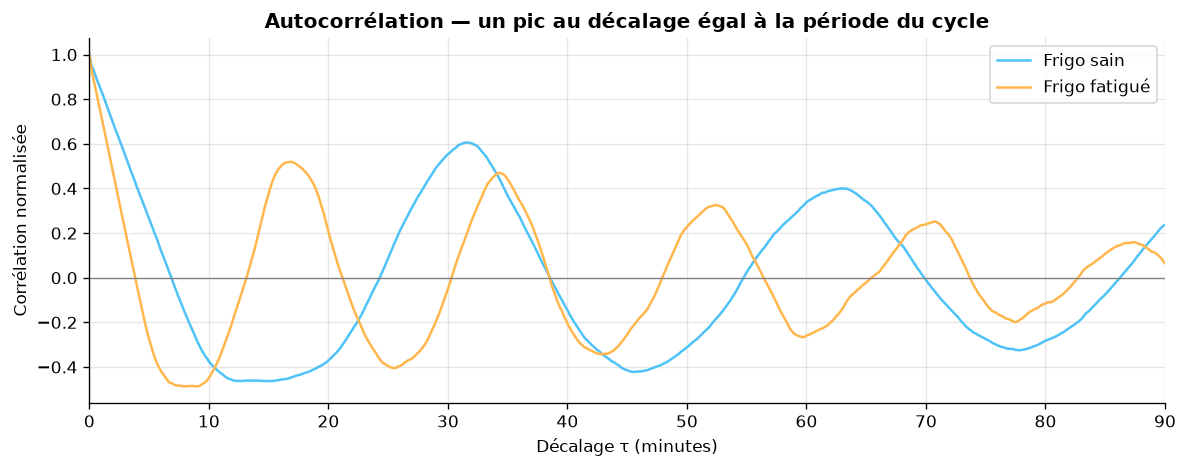

Le premier pic (hors τ=0) tombe à la période du cycle de chaque frigo —
la même information que la FFT, obtenue par un chemin totalement différent.


In [16]:
def autocorrelation(v, dt=10):
    """Autocorrélation normalisée d'un signal : renvoie (décalages en minutes, corrélation)."""
    v = np.asarray(v, dtype=float) - np.mean(v)
    n = len(v)
    corr = np.correlate(v, v, mode='full')[n - 1:]   # ne garder que les décalages >= 0
    corr = corr / corr[0]
    decalages_min = np.arange(n) * dt / 60
    return decalages_min, corr

decal_sain, corr_sain       = autocorrelation(frigo_sain)
decal_fatigue, corr_fatigue = autocorrelation(frigo_fatigue)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(decal_sain, corr_sain, color='#4fc3f7', label='Frigo sain')
ax.plot(decal_fatigue, corr_fatigue, color='#ffb74d', label='Frigo fatigué')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlim(0, 90)
ax.set_xlabel('Décalage τ (minutes)')
ax.set_ylabel('Corrélation normalisée')
ax.set_title("Autocorrélation — un pic au décalage égal à la période du cycle", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Le premier pic (hors τ=0) tombe à la période du cycle de chaque frigo —")
print("la même information que la FFT, obtenue par un chemin totalement différent.")

In [17]:
qcm(
    "Pourquoi la corrélation vaut-elle toujours 1.0 exactement à τ = 0, "
    "quel que soit le signal ?",
    [
        "C'est un bug de np.correlate",
        "À τ = 0, le signal est comparé à une copie de lui-même sans aucun décalage : "
        "il est donc parfaitement identique à lui-même, corrélation maximale par construction",
        "Parce que tous les frigos ont le même rythme",
        "1.0 est une valeur arbitraire choisie pour la normalisation",
    ],
    correct=1,
    explication="Comparer un signal à lui-même sans décalage donne toujours une corrélation "
                "parfaite — ce n'est pas une propriété du frigo, c'est une propriété "
                "mathématique de l'autocorrélation. On normalise par cette valeur (division "
                "par corr[0]) justement pour que ce point de repère soit toujours à 1.0, "
                "et que les vrais pics d'intérêt soient comparables entre signaux."
)

In [18]:
qcm(
    "Pour trouver la période du cycle, pourquoi ne peut-on pas simplement prendre "
    "le décalage où la corrélation est maximale (np.argmax sur tout le tableau) ?",
    [
        "np.argmax ne fonctionne pas sur des tableaux de corrélation",
        "Le maximum global est toujours à τ = 0 (corrélation = 1.0 par construction) : "
        "il faut écarter les tout petits décalages pour trouver le VRAI pic périodique",
        "Il faut toujours utiliser np.argmin, pas np.argmax",
        "La corrélation est toujours strictement décroissante, donc argmax est inutile",
    ],
    correct=1,
    explication="τ = 0 donne systématiquement le score maximal (1.0), et les décalages juste "
                "à côté restent élevés par simple continuité du signal. Le pic qui nous "
                "intéresse — celui qui révèle la période — est le suivant, une fois qu'on a "
                "dépassé cette zone triviale proche de τ = 0."
)

**Exercice** — écris `periode_autocorr_min(v, dt=10, decalage_min_pts=12)` qui calcule
l'autocorrélation puis trouve l'indice du maximum **en ignorant les `decalage_min_pts`
premiers points** (pour écarter la zone triviale autour de τ=0), et renvoie le décalage
correspondant en minutes. Applique-la à `frigo_fatigue` et stocke le résultat dans
`ma_periode_autocorr_fatigue`.

In [ ]:
# À toi de jouer : complète la fonction, puis applique-la à frigo_fatigue
def periode_autocorr_min(v, dt=10, decalage_min_pts=12):
    decalages, corr = autocorrelation(v, dt)
    ...

ma_periode_autocorr_fatigue = ...

In [ ]:
# Cellule de test — vérifie ta réponse ci-dessus. La cible est recalculée avec la
# même logique (indice du max au-delà de la zone triviale), pas une valeur écrite en dur.
def _reference_periode_autocorr(v, dt=10, decalage_min_pts=12):
    decalages, corr = autocorrelation(v, dt)
    idx = np.argmax(corr[decalage_min_pts:]) + decalage_min_pts
    return decalages[idx]

check("ma_periode_autocorr_fatigue", ma_periode_autocorr_fatigue,
      _reference_periode_autocorr(frigo_fatigue), tol=1.5)

In [21]:
print(f"FFT            — période frigo fatigué : {periode_dominante_min(frigo_fatigue):.1f} min")
print(f"Autocorrélation — période frigo fatigué : {_reference_periode_autocorr(frigo_fatigue):.1f} min")
print("Deux méthodes indépendantes, la même réponse physique.")

FFT            — période frigo fatigué : 17.1 min
Autocorrélation — période frigo fatigué : 16.8 min
Deux méthodes indépendantes, la même réponse physique.


![section2](pictures/cyberpunk_engraving_section2_1784108683408.png)


## 2.4 · Ondelettes — voir QUAND, pas seulement QUOI

La FFT est calculée sur tout le signal d'un coup : elle dit **quelles fréquences**
sont présentes, mais pas **à quel moment**. Si un évènement rare et localisé se
produit — par exemple une surtension passagère ou un glitch de capteur — son
énergie se disperse sur toutes les fréquences du spectre, sans créer de pic
identifiable. La FFT devient aveugle à l'instant où ça s'est produit.

Les **ondelettes** (wavelets) résolvent ce problème en gardant une notion de
position dans le temps. L'idée la plus simple, celle de Haar : comparer chaque
point à son voisin.

- **Moyenne locale** : la moyenne de deux points voisins
- **Détail local** : la différence entre ces deux points

Un détail proche de 0 = les deux points se ressemblent (signal stable).
Un détail élevé = rupture locale (transition, anomalie).

> **Remarque** : le "vrai" algorithme de Haar découpe le signal en **blocs** fixes
> non chevauchants — (points 0-1), (points 2-3), (points 4-5)... C'est ce qui le
> rend efficace pour la compression et la décomposition multi-résolution. Mais il
> a un défaut : si une transition tombe pile à la frontière entre deux blocs, ni
> l'un ni l'autre ne la voit — elle passe inaperçue. Pour repérer précisément
> **quand** un évènement rare a eu lieu, on utilise plutôt une version *glissante*
> : un détail calculé à **chaque** position, sans découpage fixe. C'est celle-ci
> qu'on utilise ci-dessous pour localiser notre anomalie.

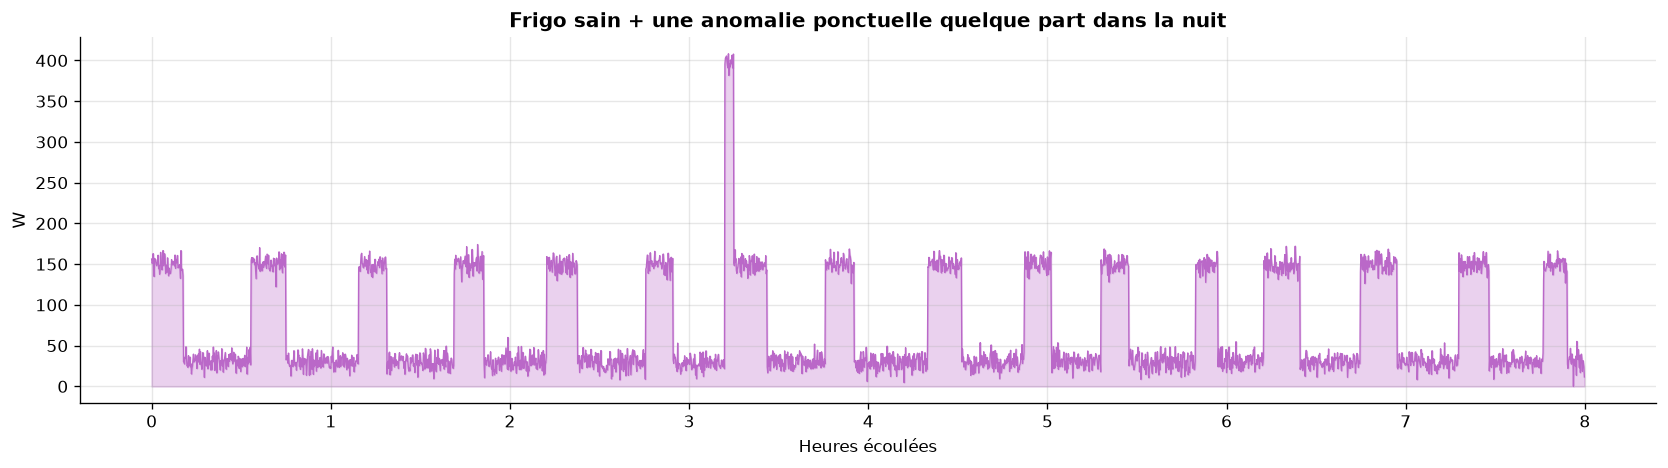

In [22]:
def anomalie(signal, heure_h=3.2, duree_min=3, dt=10, amplitude=400, seed=99):
    """Insère une anomalie ponctuelle (ex: surtension, glitch capteur) dans un signal."""
    signal = np.array(signal, dtype=float)
    rng = random.Random(seed)
    i0 = int(heure_h * 3600 / dt)
    i1 = i0 + int(duree_min * 60 / dt)
    signal[i0:i1] = [amplitude + rng.gauss(0, 8) for _ in range(i1 - i0)]
    return signal

frigo_anomalie = anomalie(frigo_sain)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(heures, frigo_anomalie, color='#ba68c8', lw=0.8)
ax.fill_between(heures, frigo_anomalie, alpha=0.3, color='#ba68c8')
ax.set_xlabel('Heures écoulées')
ax.set_ylabel('W')
ax.set_title('Frigo sain + une anomalie ponctuelle quelque part dans la nuit', fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
print(f"Période dominante — frigo sain              : {periode_dominante_min(frigo_sain):.1f} min")
print(f"Période dominante — frigo sain + anomalie    : {periode_dominante_min(frigo_anomalie):.1f} min")
print("\nLe pic dominant ne bouge presque pas : l'anomalie ne dure que 3 minutes sur 8h,")
print("son énergie est noyée dans le spectre global. On ne voit RIEN d'anormal dans la FFT.")

Période dominante — frigo sain              : 30.0 min
Période dominante — frigo sain + anomalie    : 30.0 min

Le pic dominant ne bouge presque pas : l'anomalie ne dure que 3 minutes sur 8h,
son énergie est noyée dans le spectre global. On ne voit RIEN d'anormal dans la FFT.


In [24]:
qcm(
    "D'après la comparaison des deux périodes dominantes ci-dessus, "
    "la FFT calculée sur tout le signal permet-elle de repérer facilement l'anomalie ?",
    [
        "Oui, la période dominante change nettement à cause de l'anomalie",
        "Non — un évènement court disperse son énergie sur tout le spectre, "
        "sans créer de pic identifiable ni indiquer un instant précis",
        "Oui, car toute anomalie crée automatiquement un nouveau pic",
        "Impossible à dire sans tracer le spectre complet",
    ],
    correct=1,
    explication="Une anomalie de 3 minutes sur 8h de signal (2880 points) ne représente "
                "qu'une fraction infime de l'énergie totale. La FFT résume tout le signal "
                "en un seul spectre : elle ne garde aucune information sur la position "
                "temporelle des évènements."
)

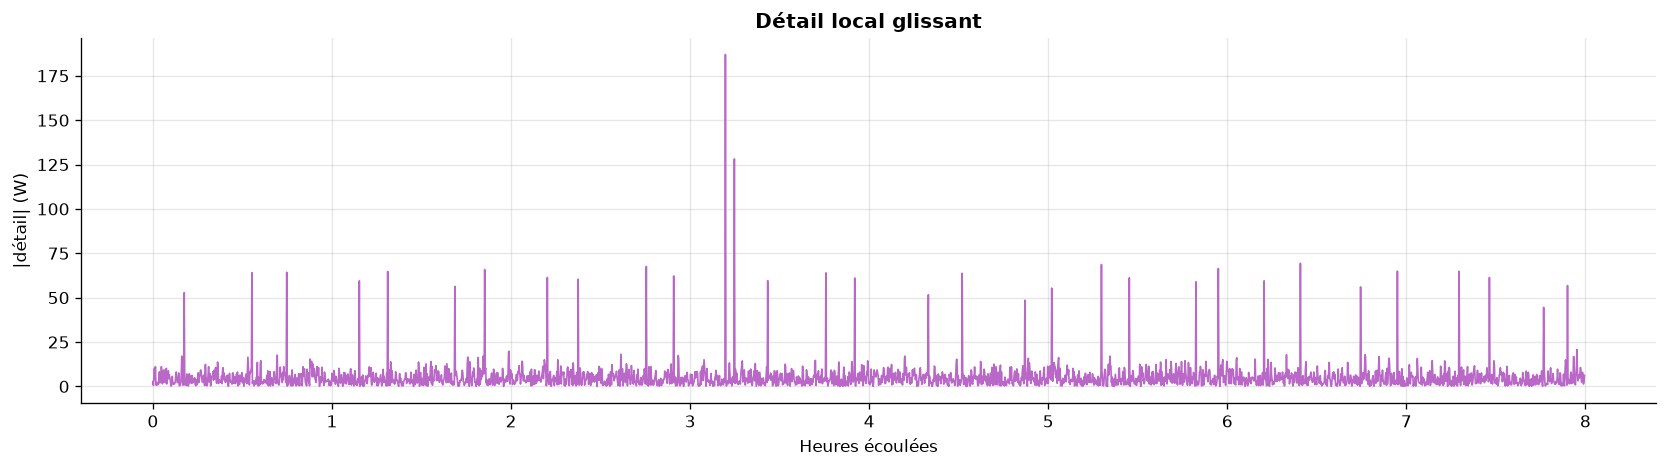

Les transitions normales du compresseur donnent des détails autour de (150-30)/2 = 60 W.
Un seul pic dépasse largement ce niveau : c'est l'anomalie, et sa position sur l'axe
des x donne directement l'instant où elle s'est produite.


In [25]:
def detail_local(v):
    """Détail glissant : demi-différence entre CHAQUE paire de points voisins.
    Ne rate jamais une transition, contrairement à un découpage en blocs fixes."""
    v = np.asarray(v, dtype=float)
    return (v[:-1] - v[1:]) / 2

def haar_step(v):
    """Un niveau de Haar 'par blocs' (le vrai algorithme, non chevauchant) :
    moyennes et détails calculés par paires fixes (0,1), (2,3), (4,5)...
    Attention : shift-variant — une transition tombant pile sur une frontière
    de bloc peut y être invisible (voir la remarque ci-dessus)."""
    v = np.asarray(v, dtype=float)
    if len(v) % 2 == 1:
        v = v[:-1]          # on tronque si le nombre de points est impair
    paires   = v.reshape(-1, 2)
    moyennes = paires.mean(axis=1)
    details  = (paires[:, 0] - paires[:, 1]) / 2
    return moyennes, details

detail   = detail_local(frigo_anomalie)
t_detail = heures[:-1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_detail, np.abs(detail), color='#ba68c8', lw=1)
ax.set_xlabel('Heures écoulées')
ax.set_ylabel('|détail| (W)')
ax.set_title("Détail local glissant", fontweight='bold')
plt.tight_layout()
plt.show()

print("Les transitions normales du compresseur donnent des détails autour de (150-30)/2 = 60 W.")
print("Un seul pic dépasse largement ce niveau : c'est l'anomalie, et sa position sur l'axe")
print("des x donne directement l'instant où elle s'est produite.")

In [26]:
qcm(
    "Sur le graphique du détail local, pourquoi le pic de l'anomalie dépasse-t-il "
    "largement les pics des transitions normales ON/OFF du compresseur ?",
    [
        "Parce que l'anomalie dure plus longtemps que les cycles normaux",
        "Parce que son amplitude (saut vers 400 W) est bien plus grande que le saut "
        "normal 30↔150 W, donc le détail local |a - b| / 2 est plus élevé",
        "Parce que les ondelettes amplifient toujours les évènements rares",
        "C'est un hasard lié au bruit gaussien",
    ],
    correct=1,
    explication="Le détail local mesure l'écart entre deux points voisins. "
                "Une transition normale saute de 30 à 150 W (détail ≈ 60 W). "
                "L'anomalie saute vers 400 W (détail ≈ 125 à 185 W selon l'état de départ) : "
                "elle se détache donc naturellement dans le graphique, à la bonne position temporelle."
)

In [27]:
qcm(
    "Pourquoi utilise-t-on un détail *glissant* (une valeur à chaque position) "
    "plutôt que le Haar *par blocs* pour localiser précisément l'anomalie ?",
    [
        "Le détail glissant est toujours plus rapide à calculer",
        "Le découpage par blocs fixes peut placer la frontière du changement "
        "exactement entre deux blocs, qui n'en voient alors ni l'un ni l'autre le saut",
        "Le Haar par blocs ne fonctionne que sur des signaux sans bruit",
        "Il n'y a en réalité aucune différence entre les deux approches",
    ],
    correct=1,
    explication="C'est le phénomène de <i>shift-variance</i> du Haar par blocs : selon où "
                "tombe la transition par rapport au découpage (0,1),(2,3),(4,5)..., elle peut "
                "être totalement invisible. Le détail glissant calcule une valeur à chaque "
                "position possible, donc ne rate jamais une transition, quel que soit son alignement."
)

**À toi de jouer** — la cellule ci-dessous est libre. Essaie `haar_step(frigo_anomalie)`
(la version par blocs) et compare le pic obtenu à celui de `detail_local` : ressort-il
aussi nettement, et au bon endroit ? Essaie aussi de changer `heure_h` ou `amplitude`
dans `anomalie()` et de relancer les cellules précédentes pour voir le pic se déplacer.

In [28]:
# Cellule libre — essaie haar_step(frigo_anomalie), ou modifie anomalie()



**Exercice** — à partir de `detail` et `t_detail`, retrouve automatiquement
(sans le lire sur le graphique) l'heure à laquelle le détail local est maximal.
Stocke le résultat dans `heure_anomalie`.

In [ ]:
# À toi de jouer : retrouve automatiquement l'heure du détail maximal
heure_anomalie = ...

In [ ]:
# Cellule de test — vérifie ta réponse ci-dessus. La cible est recalculée à partir
# de `detail`/`t_detail`, pas écrite en dur : impossible de "lire la réponse" dans
# le code de cette cellule sans faire le calcul.
_i_max_reference = np.argmax(np.abs(detail))
check("heure_anomalie", heure_anomalie, t_detail[_i_max_reference], tol=0.1)

In [31]:
print(f"Détail maximal : {abs(detail[_i_max_reference]):.0f} W, "
      f"localisé à t = {t_detail[_i_max_reference]:.2f} h")

Détail maximal : 187 W, localisé à t = 3.20 h


## 2.5 · Comparer les familles de features

On a maintenant plusieurs familles de features, chacune capturant quelque chose de
différent :

- **Partie 1** : moyenne, écart-type — le *niveau* de puissance
- **2.2** : période dominante (FFT) — le *rythme* périodique global, vu depuis le domaine fréquentiel
- **2.3** : la même période, retrouvée par autocorrélation — un chemin différent, même réponse
- **2.4** : les ondelettes localisent des ruptures ponctuelles. Pour comparer sain
  vs fatigué sur une fenêtre entière (pas un seul évènement rare), on résume le
  détail local en un seul nombre : son **énergie moyenne** — grossièrement, à quel
  point le signal est "nerveux" (beaucoup de transitions rapprochées = énergie élevée).

```python
def energie_ondelette(v):
    return np.mean(detail_local(v) ** 2)
```

Un frigo qui cycle plus vite tasse plus de transitions dans la même durée de
fenêtre : son énergie d'ondelette devrait donc être plus élevée, sans qu'on ait
besoin de calculer la moindre fréquence.

On reprend le fenêtrage (`windowing.slice_fixed`) de la Partie 1, avec des fenêtres
longues de 2h (assez pour couvrir plusieurs cycles complets), et on calcule les
trois familles de features sur chaque fenêtre.

In [32]:
def energie_ondelette(v):
    """Énergie moyenne du détail local — mesure la 'nervosité' du signal."""
    return np.mean(detail_local(v) ** 2)

import sys, os
sys.path.insert(0, os.path.abspath('.'))
import windowing as W
import pandas as pd
from datetime import datetime, timedelta, timezone

def vers_dataframe(signal, t0):
    ts = [(t0 + timedelta(seconds=i * 10)).strftime('%Y-%m-%dT%H:%M:%SZ') for i in range(len(signal))]
    return pd.DataFrame({'timestamp': ts, 'valeur_W': signal.astype(float)})

t0 = datetime(2026, 7, 6, 23, 0, 0, tzinfo=timezone.utc)
df_sain    = vers_dataframe(frigo_sain, t0)
df_fatigue = vers_dataframe(frigo_fatigue, t0)

# Fenêtres de 2h (plusieurs cycles complets), pas de 1h (50% de chevauchement)
fen_sain    = W.slice_fixed(df_sain, window_s=2 * 3600, step_s=3600)
fen_fatigue = W.slice_fixed(df_fatigue, window_s=2 * 3600, step_s=3600)

def features_rythme(valeurs):
    v = np.array(valeurs)
    return {
        'moyenne':          v.mean(),
        'ecart_type':       v.std(),
        'periode_min':      periode_dominante_min(v),
        'energie_ondelette': energie_ondelette(v),
    }

lignes = []
for f in fen_sain:
    d = features_rythme(f['values']); d['etat'] = 'sain'; lignes.append(d)
for f in fen_fatigue:
    d = features_rythme(f['values']); d['etat'] = 'fatigue'; lignes.append(d)

df_feats2 = pd.DataFrame(lignes)
print(f"{len(df_feats2)} fenêtres de 2h ({len(fen_sain)} sain + {len(fen_fatigue)} fatigué)")
print(df_feats2.round(1).to_string(index=False))

12 fenêtres de 2h (6 sain + 6 fatigué)
 moyenne  ecart_type  periode_min  energie_ondelette    etat
    72.1        57.7         30.0               69.0    sain
    68.7        56.9         30.0               76.9    sain
    70.5        57.5         30.0               74.6    sain
    70.2        57.4         30.0               65.0    sain
    67.4        56.1         30.0               76.0    sain
    72.9        57.8         30.0               84.3    sain
    72.9        58.0         17.1               95.4 fatigue
    64.7        54.9         17.1               95.8 fatigue
    64.9        54.7         17.1               99.4 fatigue
    70.2        56.9         15.0              103.5 fatigue
    71.3        57.8         17.1              108.8 fatigue
    71.7        57.6         17.1               99.3 fatigue


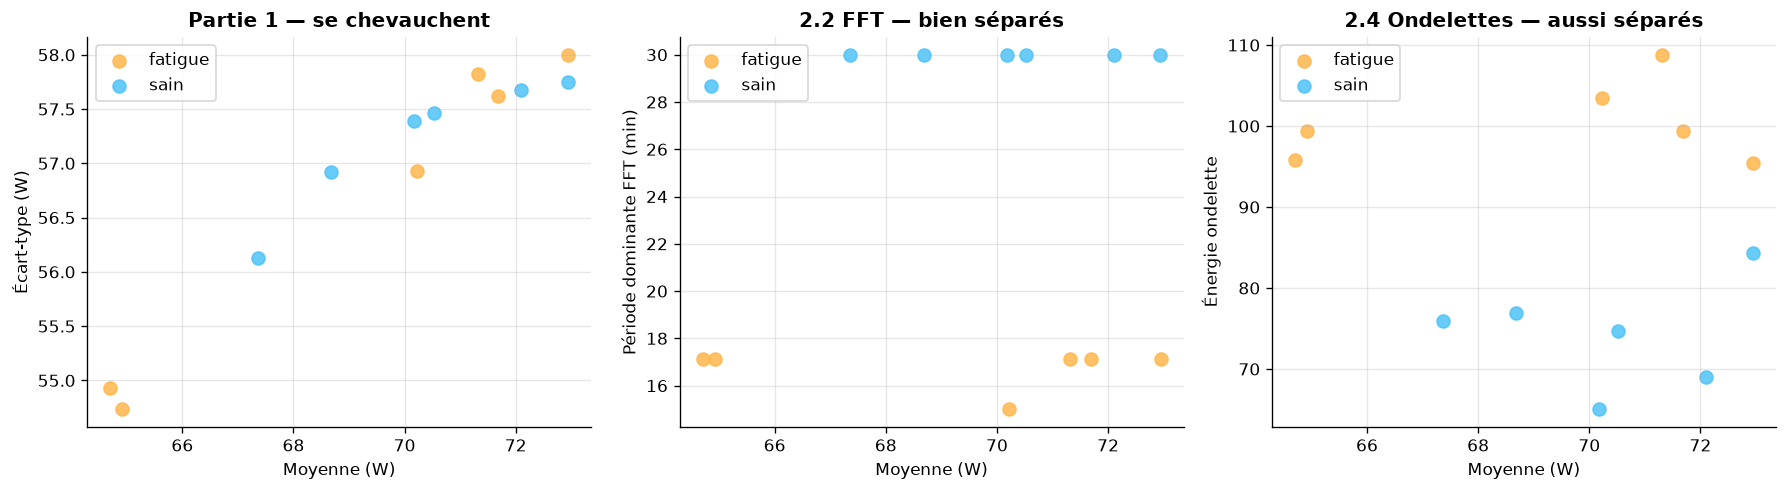

Sur l'axe 'écart-type' (Partie 1), les deux nuages se chevauchent complètement.
La période FFT ET l'énergie d'ondelette séparent toutes les deux sain/fatigué :
deux chemins différents mènent à la même conclusion — le rythme est la clé.


In [33]:
couleurs2 = {'sain': '#4fc3f7', 'fatigue': '#ffb74d'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for etat, grp in df_feats2.groupby('etat'):
    axes[0].scatter(grp['moyenne'], grp['ecart_type'], c=couleurs2[etat], label=etat, s=60, alpha=0.85)
axes[0].set_xlabel('Moyenne (W)')
axes[0].set_ylabel('Écart-type (W)')
axes[0].set_title('Partie 1 — se chevauchent', fontweight='bold')
axes[0].legend()

for etat, grp in df_feats2.groupby('etat'):
    axes[1].scatter(grp['moyenne'], grp['periode_min'], c=couleurs2[etat], label=etat, s=60, alpha=0.85)
axes[1].set_xlabel('Moyenne (W)')
axes[1].set_ylabel('Période dominante FFT (min)')
axes[1].set_title('2.2 FFT — bien séparés', fontweight='bold')
axes[1].legend()

for etat, grp in df_feats2.groupby('etat'):
    axes[2].scatter(grp['moyenne'], grp['energie_ondelette'], c=couleurs2[etat], label=etat, s=60, alpha=0.85)
axes[2].set_xlabel('Moyenne (W)')
axes[2].set_ylabel('Énergie ondelette')
axes[2].set_title('2.4 Ondelettes — aussi séparés', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Sur l'axe 'écart-type' (Partie 1), les deux nuages se chevauchent complètement.")
print("La période FFT ET l'énergie d'ondelette séparent toutes les deux sain/fatigué :")
print("deux chemins différents mènent à la même conclusion — le rythme est la clé.")

In [34]:
qcm(
    "Sur les graphiques du milieu et de droite (période FFT, énergie ondelette), "
    "les deux états sont-ils mieux séparés que sur celui de gauche (écart-type) ?",
    [
        "Non, les trois graphiques se ressemblent",
        "Oui — période FFT et énergie ondelette séparent nettement sain/fatigué, "
        "alors que moyenne et écart-type se chevauchent complètement",
        "Non, seule la FFT fonctionne, les ondelettes ne servent à rien ici",
        "Oui, mais uniquement parce qu'on a changé la taille des fenêtres",
    ],
    correct=1,
    explication="C'est exactement le point de cette partie : quand deux classes ont le même "
                "duty cycle, les features statistiques de la Partie 1 sont aveugles. Il faut "
                "une feature qui capture le <i>rythme</i> — la FFT le fait en mesurant la "
                "fréquence dominante, les ondelettes en mesurant la densité de transitions. "
                "Deux approches différentes, toutes deux efficaces ici."
)

In [35]:
qcm(
    "Pourquoi l'énergie d'ondelette est-elle plus élevée pour le frigo fatigué "
    "que pour le frigo sain, sur une fenêtre de même durée ?",
    [
        "Parce que le frigo fatigué consomme plus de puissance en moyenne",
        "Parce qu'il tasse plus de transitions ON/OFF dans la même durée : "
        "plus de grands sauts de détail local par fenêtre, donc une énergie moyenne plus élevée",
        "Parce que le bruit de mesure est plus fort sur le frigo fatigué",
        "C'est un artefact du fenêtrage, pas un effet réel",
    ],
    correct=1,
    explication="Le frigo fatigué cycle toutes les 18 min contre 30 min pour le frigo sain : "
                "sur une fenêtre de 2h, on compte donc plus de transitions ON/OFF, chacune "
                "produisant un grand coefficient de détail. Plus de grands coefficients dans "
                "la même fenêtre = énergie moyenne (détail au carré) plus élevée."
)

---
## Récapitulatif

| Feature | Ce qu'elle capture | Aveugle à... |
|---------|--------------------|--------------|
| Moyenne, écart-type (Partie 1) | Niveau de puissance, duty cycle | Le rythme des cycles |
| FFT — période dominante | Le rythme périodique global, via le domaine fréquentiel | La position temporelle des évènements |
| Autocorrélation — période dominante | Le même rythme périodique global, via une comparaison temporelle directe | La position temporelle des évènements (comme la FFT) |
| Ondelettes — énergie du détail | La densité de transitions (rythme, local) | — |
| Ondelettes — coefficient de détail max | Une rupture ponctuelle, localisée dans le temps | Les tendances lentes et globales |

Plusieurs chemins différents (FFT, autocorrélation, ondelettes) ont permis de séparer
sain/fatigué là où les statistiques simples échouaient — ce n'est pas un hasard : dès
qu'une information est **dans le rythme** plutôt que dans le niveau, il faut une feature
qui regarde le signal dans le temps ou dans les fréquences pour la récupérer. FFT et
autocorrélation arrivent d'ailleurs à la même réponse par des calculs complètement
différents — un bon signe que le rythme détecté est réel, pas un artefact de méthode.

**Prochaine étape (Partie 3)** : plusieurs appareils tournent en même temps
(frigo + lave-linge + micro-ondes + cuit-vapeur). Le signal du compteur Linky
est leur somme — on va combiner tous ces outils (stats, FFT, duty cycle) pour
les séparer.